In [1]:
import os
import glob
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import random
import cv2
import numbers
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Union
from dataclasses import dataclass, asdict
import math
def count_params(model):
    """ Count model trainable parameters """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Number of available cpu: {os.cpu_count()}')


Using device: cuda
Number of available cpu: 4


In [2]:
!pip install einops
!pip install torchsummary
!pip install hdf5storage h5py
!pip install pytorch_msssim
!pip install tqdm
!pip install albumentations
!pip install torchmetrics[image]
!pip install fvcore
!pip install thop


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 

In [3]:
# Standard library imports
import os
import json
import time
import random
import math
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional
# Third-party imports
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image, ImageOps
from tqdm.auto import tqdm
# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader
# Global constants...
TARGET_CATEGORIES = [
    "10_dress",
    "8_skirt",
    "43_ruffle",
    "1_top__t_shirt__sweatshirt",
    "0_shirt__blouse",
    "4_jacket",
    "9_coat",
    "2_sweater",
    "3_cardigan",
    "5_vest",
    "6_pants",
    "7_shorts",
]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


In [4]:
@dataclass
class PipelineConfig:
    """Configuration object for paired sketch-real samples."""
    real_root: str
    sketch_roots: Dict[str, str]
    color_json_path: Optional[str] = None
    categories: Tuple[str, ...] = tuple(TARGET_CATEGORIES)
    sketch_ratios: Dict[str, float] = None
    seed: int = 42
    def __post_init__(self):
        if self.sketch_ratios is None:
            self.sketch_ratios = {"hed": 0.5, "pencil": 0.3, "canny": 0.2}
        ratio_sum = sum(self.sketch_ratios.values())
        if not math.isclose(ratio_sum, 1.0, rel_tol=1e-6):
            raise ValueError(f"Sketch ratios must sum to 1.0, got {ratio_sum}")


In [5]:
def smart_pad_and_resize(img: Image.Image, target_size: int = 256) -> Image.Image:
    """Pad an image to a square canvas, then resize to the target resolution."""
    w, h = img.size
    max_side = max(w, h)
    # Ensure the square canvas is at least target_size to avoid up/downscale artifacts.
    canvas_side = max(max_side, target_size)
    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top
    # Use white padding to match common sketch/clean-background assumptions.
    img_padded = ImageOps.expand(
        img,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )
    if img_padded.size != (target_size, target_size):
        img_padded = img_padded.resize((target_size, target_size), Image.BICUBIC)
    return img_padded
def list_category_images(root: Path, category: str) -> Dict[str, Path]:
    """Return a mapping from filename stem to image path for one category."""
    category_dir = root / category
    if not category_dir.exists():
        return {}
    return {
        p.stem: p
        for p in category_dir.iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    }


In [6]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import json
import math
import random
import time
from collections import Counter



def load_color_lookup(color_json_path: Optional[str]) -> Dict[Tuple[str, str], dict]:
    """Load color metadata keyed by (category, original filename stem)."""
    if not color_json_path:
        print('[Color Log] Warning: color_json_path is None or empty!')
        return {}
    path = Path(color_json_path)
    if not path.exists():
        raise FileNotFoundError(f"Color JSON not found: {path}")
    print(f'[Color Log] Loading color JSON from: {path}')
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    lookup = {}
    for item in payload.get('items', []):
        category = item.get('subfolder')
        filename = item.get('filename') or Path(item.get('source_path', '')).name
        label = item.get('label')
        if not category or not filename or not label:
            continue
        stem = Path(filename).stem
        label = str(label).strip().lower()
        lookup[(category, stem)] = {
            'color_label': label,
        }
    print(f'[Color Log] Successfully loaded {len(lookup)} color items.')
    return lookup

def build_gan_pairs(config: PipelineConfig) -> Tuple[List[dict], dict]:
    """Build paired sketch-real samples."""
    print("\n[1/3] Scanning categories, matching real-sketch files, ...")
    start_time = time.time()

    real_root = Path(config.real_root)
    sketch_roots = {k: Path(v) for k, v in config.sketch_roots.items()}
    rows: List[dict] = []
    skipped_no_sketch = 0

    for category in tqdm(config.categories, desc="Scanning categories"):
        real_images = list_category_images(real_root, category)
        if not real_images:
            continue

        sketch_index = {
            method: list_category_images(root, category)
            for method, root in sketch_roots.items()
        }

        for stem, real_path in real_images.items():
            candidates = {
                method: sketch_index[method][stem]
                for method in sketch_index
                if stem in sketch_index[method]
            }
            if not candidates:
                skipped_no_sketch += 1
                continue
            rows.append(
                {
                    "category": category,
                    "filename_stem": stem,
                    "real_path": str(real_path),
                    "sketch_candidates": candidates,
                    "available_methods": sorted(candidates.keys()),
                }
            )

    print(f"Matched {len(rows)} pairs. Skipped {skipped_no_sketch} without sketches.")
    print("\n[2/3] Assigning sketch methods using ratio targets...")

    rng = random.Random(config.seed)
    total_found = len(rows)
    methods = list(config.sketch_ratios.keys())
    targets = {m: int(total_found * config.sketch_ratios[m]) for m in methods}
    remaining = dict(targets)

    indices = list(range(total_found))
    rng.shuffle(indices)

    for idx in tqdm(indices, desc="Assigning sketch method"):
        row = rows[idx]
        available = row["available_methods"]
        preferred = [m for m in available if remaining.get(m, 0) > 0]
        method = rng.choice(preferred) if preferred else rng.choice(available)

        row["sketch_method"] = method
        row["sketch_path"] = str(row["sketch_candidates"][method])
        if method in remaining:
            remaining[method] -= 1

    final_rows = [
        {
            "category": r["category"],
            "filename_stem": r["filename_stem"],
            "real_path": r["real_path"],
            "sketch_path": r["sketch_path"],
            "sketch_method": r["sketch_method"],
        }
        for r in rows
    ]

    duration = time.time() - start_time
    print(f"Data preparation completed in {duration:.2f}s.")

    summary = {
        "num_pairs": len(final_rows),
        "sketch_method_counts": dict(Counter(r["sketch_method"] for r in final_rows)),
        "skipped_no_sketch": skipped_no_sketch,
    }
    return final_rows, summary

In [7]:
# Cell 5
import os
from typing import List, Tuple, Optional
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class SketchToRealGANDataset(Dataset):
    """PyTorch dataset that loads paired sketch-real images ."""

    def __init__(
        self,
        rows: List[dict],
        image_size: int = 256,
        apply_augmentation: bool = False,
        flip_prob: float = 0.5,
        crop_scale: Tuple[float, float] = (0.9, 1.0),
        max_translate_ratio: float = 0.08,
        max_rotation_deg: float = 10.0,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        # Thêm các tham số cho việc làm đứt nét Sketch
        sketch_degrade_prob: float = 0.7,
        degrade_holes_range: Tuple[int, int] = (5, 20),
        degrade_size_range: Tuple[int, int] = (10, 40),
    ):
        self.rows = rows
        self.image_size = image_size
        self.apply_augmentation = apply_augmentation
        
        # --- 1. SPATIAL AUGMENTATION (Áp dụng chung cho cả Real và Sketch để giữ align) ---
        max_shift_percent = max_translate_ratio * 100.0
        self._spatial_augment = A.Compose(
            [
                A.HorizontalFlip(p=flip_prob),
                A.RandomResizedCrop(
                    size=(self.image_size, self.image_size),
                    scale=crop_scale,
                    ratio=(1.0, 1.0),
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.Affine(
                    scale=scale_range,
                    translate_percent={"x": (-max_shift_percent / 100.0, max_shift_percent / 100.0), "y": (-max_shift_percent / 100.0, max_shift_percent / 100.0)},
                    rotate=(-max_rotation_deg, max_rotation_deg),
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255),
                    p=1.0,
                ),
            ],
            additional_targets={"real": "image"},
        )

        # --- 2. SKETCH DEGRADATION (Chỉ áp dụng cho Sketch để ép model học nội suy) ---
        self._sketch_only_augment = A.Compose(
            [
                # Làm đứt nét bằng cách xóa ngẫu nhiên các ô vuông (tô màu trắng)
                A.CoarseDropout(
                    max_holes=degrade_holes_range[1],
                    min_holes=degrade_holes_range[0],
                    max_height=degrade_size_range[1],
                    max_width=degrade_size_range[1],
                    min_height=degrade_size_range[0],
                    min_width=degrade_size_range[0],
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob
                ),
                # Làm méo/xô lệch nét vẽ nhẹ
                A.ElasticTransform(
                    alpha=300, sigma=10,
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob * 0.7
                ),
            ]
        )

    def _load_img(self, path: str) -> np.ndarray:
        with Image.open(path) as src_img:
            img = src_img.convert("RGB")
        # Giả định hàm smart_pad_and_resize đã được định nghĩa ở Cell 3
        img = smart_pad_and_resize(img, target_size=self.image_size)
        return np.asarray(img, dtype=np.uint8)

    def _apply_spatial_augment_pair(
        self,
        sketch_img: np.ndarray,
        real_img: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        transformed = self._spatial_augment(image=sketch_img, real=real_img)
        return transformed["image"], transformed["real"]

    def _to_tensor(self, img: np.ndarray) -> torch.Tensor:
        arr = img.astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        sketch_img = self._load_img(row["sketch_path"])
        real_img = self._load_img(row["real_path"])
        
        if self.apply_augmentation:
            # Bước 1: Augment không gian cho cả 2 ảnh để giữ sự đồng nhất
            sketch_img, real_img = self._apply_spatial_augment_pair(sketch_img, real_img)
            
            # Bước 2: Chỉ làm hỏng (degrade) ảnh Sketch
            sketch_img = self._sketch_only_augment(image=sketch_img)["image"]

        return {
            "sketch": self._to_tensor(sketch_img),
            "real": self._to_tensor(real_img),
            "filename_stem": row["filename_stem"],
            "category": row.get("category", ""),
            "category": row["category"],
        }


def build_gan_dataloader(
    rows: List[dict],
    batch_size: int = 16,
    image_size: int = 256,
    shuffle: bool = True,
    num_workers: Optional[int] = None,
    apply_augmentation: bool = False,
    sketch_degrade_prob: float = 0.7, 
) -> DataLoader:
    """Build a DataLoader from paired metadata rows."""
    if num_workers is None:
        num_workers = 0 if os.name == "nt" else max(1, min(4, (os.cpu_count() or 2) // 2))

    dataset = SketchToRealGANDataset(
        rows=rows,
        image_size=image_size,
        apply_augmentation=apply_augmentation,
        sketch_degrade_prob=sketch_degrade_prob,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


In [8]:
print("Starting data pipeline for EVALUATION...")
PIPE_CFG = PipelineConfig(
    real_root="/kaggle/input/datasets/vunhuduc/val-fashion/(3)_images_filtered",
    sketch_roots={
        "pencil": "/kaggle/input/datasets/vunhuduc/val-sketch-pencil/(4)_sketch_pencil",
    },
    sketch_ratios={"pencil": 1.0},
    color_json_path="/kaggle/input/datasets/vunhuduc/color-info-11/color_info.json",
)
eval_rows, eval_summary = build_gan_pairs(PIPE_CFG)
print("\n" + "=" * 30)
print("EVALUATION PIPELINE SUMMARY:")
print(f"- Total paired samples: {eval_summary['num_pairs']}")
for method, count in eval_summary["sketch_method_counts"].items():
    print(f"  + {method}: {count} samples")
print("=" * 30)
eval_loader = build_gan_dataloader(
    rows=eval_rows,
    batch_size=16,
    image_size=256,
    shuffle=False,  # Don't shuffle for eval
    apply_augmentation=False, # No augmentation for evaluation
)
print(f"DataLoader ready. Total batches: {len(eval_loader)}")


Starting data pipeline for EVALUATION...

[1/3] Scanning categories, matching real-sketch files, ...


Scanning categories:   0%|          | 0/12 [00:00<?, ?it/s]

Matched 1708 pairs. Skipped 0 without sketches.

[2/3] Assigning sketch methods using ratio targets...


Assigning sketch method:   0%|          | 0/1708 [00:00<?, ?it/s]

Data preparation completed in 0.27s.

EVALUATION PIPELINE SUMMARY:
- Total paired samples: 1708
  + pencil: 1708 samples
DataLoader ready. Total batches: 107


/tmp/ipykernel_24/2108878725.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


## MUNIT Architecture Components

This section contains the MUNIT building blocks: ResBlocks, Encoders, Decoders.


In [9]:
"""
Copyright (C) 2018 NVIDIA Corporation.  All rights reserved.
Licensed under the CC BY-NC-SA 4.0 license (https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode).
"""
from torch import nn
from torch.autograd import Variable
import torch
import torch.nn.functional as F
try:
    from itertools import izip as zip
except ImportError: # will be 3.x series
    pass

##################################################################################
# Discriminator
##################################################################################

class MsImageDis(nn.Module):
    # Multi-scale discriminator architecture
    def __init__(self, input_dim, params):
        super(MsImageDis, self).__init__()
        self.n_layer = params['n_layer']
        self.gan_type = params['gan_type']
        self.dim = params['dim']
        self.norm = params['norm']
        self.activ = params['activ']
        self.num_scales = params['num_scales']
        self.pad_type = params['pad_type']
        self.input_dim = input_dim
        self.downsample = nn.AvgPool2d(3, stride=2, padding=[1, 1], count_include_pad=False)
        self.cnns = nn.ModuleList()
        for _ in range(self.num_scales):
            self.cnns.append(self._make_net())

    def _make_net(self):
        dim = self.dim
        cnn_x = []
        cnn_x += [Conv2dBlock(self.input_dim, dim, 4, 2, 1, norm='none', activation=self.activ, pad_type=self.pad_type)]
        for i in range(self.n_layer - 1):
            cnn_x += [Conv2dBlock(dim, dim * 2, 4, 2, 1, norm=self.norm, activation=self.activ, pad_type=self.pad_type)]
            dim *= 2
        cnn_x += [nn.Conv2d(dim, 1, 1, 1, 0)]
        cnn_x = nn.Sequential(*cnn_x)
        return cnn_x

    def forward(self, x):
        outputs = []
        for model in self.cnns:
            outputs.append(model(x))
            x = self.downsample(x)
        return outputs

    def calc_dis_loss(self, input_fake, input_real):
        # calculate the loss to train D
        outs0 = self.forward(input_fake)
        outs1 = self.forward(input_real)
        loss = 0

        for it, (out0, out1) in enumerate(zip(outs0, outs1)):
            if self.gan_type == 'lsgan':
                loss += F.mse_loss(out0, torch.zeros_like(out0)) + F.mse_loss(out1, torch.ones_like(out1))
            elif self.gan_type == 'nsgan':
                all0 = Variable(torch.zeros_like(out0.data).cuda(), requires_grad=False)
                all1 = Variable(torch.ones_like(out1.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all0) +
                                   F.binary_cross_entropy(F.sigmoid(out1), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

    def calc_gen_loss(self, input_fake):
        # calculate the loss to train G
        outs0 = self.forward(input_fake)
        loss = 0
        for it, (out0) in enumerate(outs0):
            if self.gan_type == 'lsgan':
                loss += F.mse_loss(out0, torch.ones_like(out0)) # LSGAN
            elif self.gan_type == 'nsgan':
                all1 = Variable(torch.ones_like(out0.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

##################################################################################
# Generator
##################################################################################

class AdaINGen(nn.Module):
    # AdaIN auto-encoder architecture
    def __init__(self, input_dim, params):
        super(AdaINGen, self).__init__()
        dim = params['dim']
        style_dim = params['style_dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']
        mlp_dim = params['mlp_dim']

        # style encoder
        self.enc_style = StyleEncoder(4, input_dim, dim, style_dim, norm='none', activ=activ, pad_type=pad_type)

        # content encoder
        self.enc_content = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc_content.output_dim, input_dim, res_norm='adain', activ=activ, pad_type=pad_type)

        # MLP to generate AdaIN parameters
        self.mlp = MLP(style_dim, self.get_num_adain_params(self.dec), mlp_dim, 3, norm='none', activ=activ)

    def forward(self, images):
        # reconstruct an image
        content, style_fake = self.encode(images)
        images_recon = self.decode(content, style_fake)
        return images_recon

    def encode(self, images):
        # encode an image to its content and style codes
        style_fake = self.enc_style(images)
        content = self.enc_content(images)
        return content, style_fake

    def decode(self, content, style, style_weight=1.0):
        # decode content and style codes to an image
        adain_params = self.mlp(style)
        self.assign_adain_params(adain_params, self.dec, style_weight)
        images = self.dec(content)
        return images

    def assign_adain_params(self, adain_params, model, style_weight=1.0):
        # assign the adain_params to the AdaIN layers in model
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                mean = adain_params[:, :m.num_features]
                std = adain_params[:, m.num_features:2*m.num_features]
                m.bias = (mean * style_weight).contiguous().view(-1)
                m.weight = (std * style_weight).contiguous().view(-1)
                if adain_params.size(1) > 2*m.num_features:
                    adain_params = adain_params[:, 2*m.num_features:]

    def get_num_adain_params(self, model):
        # return the number of AdaIN parameters needed by the model
        num_adain_params = 0
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                num_adain_params += 2*m.num_features
        return num_adain_params


class VAEGen(nn.Module):
    # VAE architecture
    def __init__(self, input_dim, params):
        super(VAEGen, self).__init__()
        dim = params['dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']

        # content encoder
        self.enc = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc.output_dim, input_dim, res_norm='in', activ=activ, pad_type=pad_type)

    def forward(self, images):
        # This is a reduced VAE implementation where we assume the outputs are multivariate Gaussian distribution with mean = hiddens and std_dev = all ones.
        hiddens = self.encode(images)
        if self.training == True:
            noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
            images_recon = self.decode(hiddens + noise)
        else:
            images_recon = self.decode(hiddens)
        return images_recon, hiddens

    def encode(self, images):
        hiddens = self.enc(images)
        noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
        return hiddens, noise

    def decode(self, hiddens):
        images = self.dec(hiddens)
        return images


##################################################################################
# Encoder and Decoders
##################################################################################

class StyleEncoder(nn.Module):
    def __init__(self, n_downsample, input_dim, dim, style_dim, norm, activ, pad_type):
        super(StyleEncoder, self).__init__()
        self.model = []
        self.model += [Conv2dBlock(input_dim, dim, 7, 1, 3, norm=norm, activation=activ, pad_type=pad_type)]
        for i in range(2):
            self.model += [Conv2dBlock(dim, 2 * dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
            dim *= 2
        for i in range(n_downsample - 2):
            self.model += [Conv2dBlock(dim, dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
        self.model += [nn.AdaptiveAvgPool2d(1)] # global average pooling
        self.model += [nn.Conv2d(dim, style_dim, 1, 1, 0)]
        self.model = nn.Sequential(*self.model)
        self.output_dim = dim

    def forward(self, x):
        return self.model(x)

class ContentEncoder(nn.Module):
    def __init__(self, n_downsample, n_res, input_dim, dim, norm, activ, pad_type):
        super(ContentEncoder, self).__init__()
        self.model = []
        self.model += [Conv2dBlock(input_dim, dim, 7, 1, 3, norm=norm, activation=activ, pad_type=pad_type)]
        # downsampling blocks
        for i in range(n_downsample):
            self.model += [Conv2dBlock(dim, 2 * dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
            dim *= 2
        # residual blocks
        self.model += [ResBlocks(n_res, dim, norm=norm, activation=activ, pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)
        self.output_dim = dim

    def forward(self, x):
        return self.model(x)

class Decoder(nn.Module):
    def __init__(self, n_upsample, n_res, dim, output_dim, res_norm='adain', activ='relu', pad_type='zero'):
        super(Decoder, self).__init__()

        self.model = []
        # AdaIN residual blocks
        self.model += [ResBlocks(n_res, dim, res_norm, activ, pad_type=pad_type)]
        # upsampling blocks
        for i in range(n_upsample):
            self.model += [nn.Upsample(scale_factor=2),
                           Conv2dBlock(dim, dim // 2, 5, 1, 2, norm='ln', activation=activ, pad_type=pad_type)]
            dim //= 2
        # use reflection padding in the last conv layer
        self.model += [Conv2dBlock(dim, output_dim, 7, 1, 3, norm='none', activation='tanh', pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x)

##################################################################################
# Sequential Models
##################################################################################
class ResBlocks(nn.Module):
    def __init__(self, num_blocks, dim, norm='in', activation='relu', pad_type='zero'):
        super(ResBlocks, self).__init__()
        self.model = []
        for i in range(num_blocks):
            self.model += [ResBlock(dim, norm=norm, activation=activation, pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x)

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, dim, n_blk, norm='none', activ='relu'):

        super(MLP, self).__init__()
        self.model = []
        self.model += [LinearBlock(input_dim, dim, norm=norm, activation=activ)]
        for i in range(n_blk - 2):
            self.model += [LinearBlock(dim, dim, norm=norm, activation=activ)]
        self.model += [LinearBlock(dim, output_dim, norm='none', activation='none')] # no output activations
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

##################################################################################
# Basic Blocks
##################################################################################
class ResBlock(nn.Module):
    def __init__(self, dim, norm='in', activation='relu', pad_type='zero'):
        super(ResBlock, self).__init__()

        model = []
        model += [Conv2dBlock(dim ,dim, 3, 1, 1, norm=norm, activation=activation, pad_type=pad_type)]
        model += [Conv2dBlock(dim ,dim, 3, 1, 1, norm=norm, activation='none', pad_type=pad_type)]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        residual = x
        out = self.model(x)
        out += residual
        return out

class Conv2dBlock(nn.Module):
    def __init__(self, input_dim ,output_dim, kernel_size, stride,
                 padding=0, norm='none', activation='relu', pad_type='zero'):
        super(Conv2dBlock, self).__init__()
        self.use_bias = True
        # initialize padding
        if pad_type == 'reflect':
            self.pad = nn.ReflectionPad2d(padding)
        elif pad_type == 'replicate':
            self.pad = nn.ReplicationPad2d(padding)
        elif pad_type == 'zero':
            self.pad = nn.ZeroPad2d(padding)
        else:
            assert 0, "Unsupported padding type: {}".format(pad_type)

        # initialize normalization
        norm_dim = output_dim
        if norm == 'bn':
            self.norm = nn.BatchNorm2d(norm_dim)
        elif norm == 'in':
            #self.norm = nn.InstanceNorm2d(norm_dim, track_running_stats=True)
            self.norm = nn.InstanceNorm2d(norm_dim)
        elif norm == 'ln':
            self.norm = LayerNorm(norm_dim)
        elif norm == 'adain':
            self.norm = AdaptiveInstanceNorm2d(norm_dim)
        elif norm == 'none' or norm == 'sn':
            self.norm = None
        else:
            assert 0, "Unsupported normalization: {}".format(norm)

        # initialize activation
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'lrelu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'prelu':
            self.activation = nn.PReLU()
        elif activation == 'selu':
            self.activation = nn.SELU(inplace=True)
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'none':
            self.activation = None
        else:
            assert 0, "Unsupported activation: {}".format(activation)

        # initialize convolution
        if norm == 'sn':
            self.conv = SpectralNorm(nn.Conv2d(input_dim, output_dim, kernel_size, stride, bias=self.use_bias))
        else:
            self.conv = nn.Conv2d(input_dim, output_dim, kernel_size, stride, bias=self.use_bias)

    def forward(self, x):
        x = self.conv(self.pad(x))
        if self.norm:
            x = self.norm(x)
        if self.activation:
            x = self.activation(x)
        return x

class LinearBlock(nn.Module):
    def __init__(self, input_dim, output_dim, norm='none', activation='relu'):
        super(LinearBlock, self).__init__()
        use_bias = True
        # initialize fully connected layer
        if norm == 'sn':
            self.fc = SpectralNorm(nn.Linear(input_dim, output_dim, bias=use_bias))
        else:
            self.fc = nn.Linear(input_dim, output_dim, bias=use_bias)

        # initialize normalization
        norm_dim = output_dim
        if norm == 'bn':
            self.norm = nn.BatchNorm1d(norm_dim)
        elif norm == 'in':
            self.norm = nn.InstanceNorm1d(norm_dim)
        elif norm == 'ln':
            self.norm = LayerNorm(norm_dim)
        elif norm == 'none' or norm == 'sn':
            self.norm = None
        else:
            assert 0, "Unsupported normalization: {}".format(norm)

        # initialize activation
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'lrelu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'prelu':
            self.activation = nn.PReLU()
        elif activation == 'selu':
            self.activation = nn.SELU(inplace=True)
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'none':
            self.activation = None
        else:
            assert 0, "Unsupported activation: {}".format(activation)

    def forward(self, x):
        out = self.fc(x)
        if self.norm:
            out = self.norm(out)
        if self.activation:
            out = self.activation(out)
        return out

##################################################################################
# VGG network definition
##################################################################################
class Vgg16(nn.Module):
    def __init__(self):
        super(Vgg16, self).__init__()
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)

        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)

        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)

        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)

        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)

    def forward(self, X):
        h = F.relu(self.conv1_1(X), inplace=True)
        h = F.relu(self.conv1_2(h), inplace=True)
        # relu1_2 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv2_1(h), inplace=True)
        h = F.relu(self.conv2_2(h), inplace=True)
        # relu2_2 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv3_1(h), inplace=True)
        h = F.relu(self.conv3_2(h), inplace=True)
        h = F.relu(self.conv3_3(h), inplace=True)
        # relu3_3 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv4_1(h), inplace=True)
        h = F.relu(self.conv4_2(h), inplace=True)
        h = F.relu(self.conv4_3(h), inplace=True)
        # relu4_3 = h

        h = F.relu(self.conv5_1(h), inplace=True)
        h = F.relu(self.conv5_2(h), inplace=True)
        h = F.relu(self.conv5_3(h), inplace=True)
        relu5_3 = h

        return relu5_3
        # return [relu1_2, relu2_2, relu3_3, relu4_3]

##################################################################################
# Normalization layers
##################################################################################
class AdaptiveInstanceNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(AdaptiveInstanceNorm2d, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        # weight and bias are dynamically assigned
        self.weight = None
        self.bias = None
        # just dummy buffers, not used
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

    def forward(self, x):
        assert self.weight is not None and self.bias is not None, "Please assign weight and bias before calling AdaIN!"
        b, c = x.size(0), x.size(1)
        
        # Cast inputs and parameters to float32 to prevent fp16 overflow in AMP
        x_f32 = x.float()
        weight_f32 = self.weight.float()
        bias_f32 = self.bias.float()
        running_mean = self.running_mean.repeat(b).type_as(x_f32)
        running_var = self.running_var.repeat(b).type_as(x_f32)

        # Apply instance norm in fp32
        x_reshaped = x_f32.contiguous().view(1, b * c, *x_f32.size()[2:])

        out = F.batch_norm(
            x_reshaped, running_mean, running_var, weight_f32, bias_f32,
            True, self.momentum, self.eps)

        return out.view(b, c, *x.size()[2:]).to(x.dtype)

    def __repr__(self):
        return self.__class__.__name__ + '(' + str(self.num_features) + ')'


class LayerNorm(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super(LayerNorm, self).__init__()
        self.num_features = num_features
        self.affine = affine
        self.eps = eps

        if self.affine:
            self.gamma = nn.Parameter(torch.Tensor(num_features).uniform_())
            self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x):
        shape = [-1] + [1] * (x.dim() - 1)
        # print(x.size())
        x_f32 = x.float()
        if x.size(0) == 1:
            # These two lines run much faster in pytorch 0.4 than the two lines listed below.
            mean = x_f32.view(-1).mean().view(*shape)
            std = x_f32.view(-1).std(unbiased=False).view(*shape)
        else:
            mean = x_f32.view(x.size(0), -1).mean(1).view(*shape)
            std = x_f32.view(x.size(0), -1).std(1, unbiased=False).view(*shape)

        out = (x_f32 - mean) / (std + self.eps)
        out = out.to(x.dtype)

        if self.affine:
            shape = [1, -1] + [1] * (x.dim() - 2)
            out = out * self.gamma.view(*shape) + self.beta.view(*shape)
        return out

def l2normalize(v, eps=1e-12):
    return v / (v.norm() + eps)


class SpectralNorm(nn.Module):
    """
    Based on the paper "Spectral Normalization for Generative Adversarial Networks" by Takeru Miyato, Toshiki Kataoka, Masanori Koyama, Yuichi Yoshida
    and the Pytorch implementation https://github.com/christiancosgrove/pytorch-spectral-normalization-gan
    """
    def __init__(self, module, name='weight', power_iterations=1):
        super(SpectralNorm, self).__init__()
        self.module = module
        self.name = name
        self.power_iterations = power_iterations
        if not self._made_params():
            self._make_params()

    def _update_u_v(self):
        u = getattr(self.module, self.name + "_u")
        v = getattr(self.module, self.name + "_v")
        w = getattr(self.module, self.name + "_bar")

        height = w.data.shape[0]
        for _ in range(self.power_iterations):
            v.data = l2normalize(torch.mv(torch.t(w.view(height,-1).data), u.data))
            u.data = l2normalize(torch.mv(w.view(height,-1).data, v.data))

        # sigma = torch.dot(u.data, torch.mv(w.view(height,-1).data, v.data))
        sigma = u.dot(w.view(height, -1).mv(v))
        setattr(self.module, self.name, w / sigma.expand_as(w))

    def _made_params(self):
        try:
            u = getattr(self.module, self.name + "_u")
            v = getattr(self.module, self.name + "_v")
            w = getattr(self.module, self.name + "_bar")
            return True
        except AttributeError:
            return False


    def _make_params(self):
        w = getattr(self.module, self.name)

        height = w.data.shape[0]
        width = w.view(height, -1).data.shape[1]

        u = nn.Parameter(w.data.new(height).normal_(0, 1), requires_grad=False)
        v = nn.Parameter(w.data.new(width).normal_(0, 1), requires_grad=False)
        u.data = l2normalize(u.data)
        v.data = l2normalize(v.data)
        w_bar = nn.Parameter(w.data)

        del self.module._parameters[self.name]

        self.module.register_parameter(self.name + "_u", u)
        self.module.register_parameter(self.name + "_v", v)
        self.module.register_parameter(self.name + "_bar", w_bar)


    def forward(self, *args):
        self._update_u_v()
        return self.module.forward(*args)

class MUNIT(nn.Module):
    def __init__(self, gen_params):
        super().__init__()
        self.gen_a = AdaINGen(3, gen_params)
        self.gen_b = AdaINGen(3, gen_params)

    def encode(self, x, domain):
        if domain == 'A':
            return self.gen_a.encode(x)
        else:
            return self.gen_b.encode(x)

    def decode(self, c, s, domain, style_weight=1.0):
        if domain == 'A':
            return self.gen_a.decode(c, s, style_weight)
        else:
            return self.gen_b.decode(c, s, style_weight)

    def forward(self, x_a, x_b):
        # encode
        c_a, s_a_fake = self.encode(x_a, 'A')
        c_b, s_b_fake = self.encode(x_b, 'B')
        # decode (within domain)
        x_a_recon = self.decode(c_a, s_a_fake, 'A')
        x_b_recon = self.decode(c_b, s_b_fake, 'B')
        # decode (cross domain)
        x_ba = self.decode(c_b, s_a_fake, 'A')
        x_ab = self.decode(c_a, s_b_fake, 'B')
        # encode again
        c_b_recon, s_a_recon = self.encode(x_ba, 'A')
        c_a_recon, s_b_recon = self.encode(x_ab, 'B')
        return x_a_recon, x_b_recon, x_ba, x_ab, c_a, c_b, s_a_fake, s_b_fake, c_a_recon, c_b_recon, s_a_recon, s_b_recon


In [10]:
# Compatibility patch for some Kaggle runtimes where torch._dynamo.disable
# does not accept the `wrapping` keyword used internally by torch optimizer setup.
import inspect
import torch.optim.optimizer as torch_optimizer_module
def patch_torch_dynamo_disable():
    if not hasattr(torch, "_dynamo") or not hasattr(torch._dynamo, "disable"):
        return False
    original_disable = torch._dynamo.disable
    try:
        sig = inspect.signature(original_disable)
    except Exception:
        return False
    if "wrapping" in sig.parameters:
        return False
    def disable_compat(fn=None, recursive=True, wrapping=None, *args, **kwargs):
        # Ignore unsupported args and forward only parameters accepted by old signature.
        if fn is None:
            try:
                return original_disable(recursive=recursive)
            except TypeError:
                return original_disable()
        try:
            return original_disable(fn=fn, recursive=recursive)
        except TypeError:
            return original_disable(fn)
    torch._dynamo.disable = disable_compat
    return True
def patch_optimizer_disable_wrapper():
    # If Optimizer.__init__ was already wrapped by a broken dynamo-disable decorator,
    # unwrap it to the original function.
    init_fn = torch_optimizer_module.Optimizer.__init__
    if hasattr(init_fn, "__wrapped__"):
        torch_optimizer_module.Optimizer.__init__ = init_fn.__wrapped__
        return True
    return False
patched_disable = patch_torch_dynamo_disable()
patched_optimizer = patch_optimizer_disable_wrapper()
print("Patched torch._dynamo.disable:", patched_disable)
print("Patched Optimizer.__init__ wrapper:", patched_optimizer)


Patched torch._dynamo.disable: False
Patched Optimizer.__init__ wrapper: False


In [11]:
def denormalize_tensor(x):
    return (x.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
import matplotlib.pyplot as plt
import numpy as np
def save_sample_grid(sketch_batch, fake_batch, real_batch, out_path=None, max_items=4):
    n = min(max_items, sketch_batch.size(0), fake_batch.size(0), real_batch.size(0))
    if n == 0:
        return
    sketch_batch = denormalize_tensor(sketch_batch[:n])
    fake_batch = denormalize_tensor(fake_batch[:n])
    real_batch = denormalize_tensor(real_batch[:n])
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    column_titles = ['Sketch', 'Generated', 'Real']
    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title)
    for row_idx in range(n):
        for col_idx, tensor in enumerate([sketch_batch, fake_batch, real_batch]):
            img = tensor[row_idx].permute(1, 2, 0).numpy()
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


In [ ]:
import torch
from pathlib import Path
def load_generator_weights(ckpt_path, model, strict=True):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
    print(f"Loading weights from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if 'munit_state_dict' in ckpt:
        model.load_state_dict(ckpt['munit_state_dict'], strict=strict)
    elif 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'], strict=strict)
    elif 'netG_state_dict' in ckpt:
        model.load_state_dict(ckpt['netG_state_dict'], strict=strict)
    else:
        # Fallback if checkpoint only contains state dict directly
        model.load_state_dict(ckpt, strict=strict)
        
    print("Weights loaded successfully.")

# Infer

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LPIPSEvaluator:
    def __init__(self, device='cuda'):
        self.device = device
        self.enabled = False
        try:
            import lpips
            print("Loading LPIPS model (net='alex')...")
            self.loss_fn = lpips.LPIPS(net='alex').to(device)
            self.loss_fn.eval()
            self.enabled = True
            self.method = "lpips_lib"
            print("LPIPS model loaded successfully via lpips library.")
            return
        except Exception as e:
            pass
            
        try:
            from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
            print("Loading LPIPS model (net_type='alex') via torchmetrics...")
            self.metric = LearnedPerceptualImagePatchSimilarity(net_type='alex', normalize=True).to(device)
            self.enabled = True
            self.method = "torchmetrics"
            print("LPIPS model loaded successfully via torchmetrics.")
        except Exception as e:
            print(f"Warning: Could not load LPIPS model. LPIPS metric will be skipped. Error: {e}")
            
    def compute(self, fake_images_01, real_images_01):
        if not self.enabled:
            return 0.0, 0
        try:
            if self.method == "lpips_lib":
                fake_sub11 = fake_images_01 * 2.0 - 1.0
                real_sub11 = real_images_01 * 2.0 - 1.0
                with torch.no_grad():
                    dist = self.loss_fn(fake_sub11, real_sub11)
                return dist.sum().item(), len(dist)
            elif self.method == "torchmetrics":
                with torch.no_grad():
                    score = self.metric(fake_images_01, real_images_01)
                return score.item() * len(fake_images_01), len(fake_images_01)
        except Exception as e:
            return 0.0, 0

class CLIPEvaluator:
    def __init__(self, device='cuda'):
        self.device = device
        self.enabled = False
        try:
            from transformers import CLIPProcessor, CLIPModel
            print("Loading CLIP model (openai/clip-vit-base-patch32) for CLIP-S metric...")
            self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
            self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            self.model.eval()
            self.enabled = True
            print("CLIP model loaded successfully.")
        except Exception as e:
            print(f"Warning: Could not load CLIP model. CLIP-S metric will be skipped. Error: {e}")
            
    def compute_image_image_similarity(self, fake_images_01, real_images_01):
        if not self.enabled:
            return 0.0, 0
        from PIL import Image
        import numpy as np
        import torch
        import torch.nn.functional as F
        fake_pil = [Image.fromarray(np.clip(img.permute(1, 2, 0).cpu().numpy() * 255.0, 0, 255).astype(np.uint8)) for img in fake_images_01]
        real_pil = [Image.fromarray(np.clip(img.permute(1, 2, 0).cpu().numpy() * 255.0, 0, 255).astype(np.uint8)) for img in real_images_01]
        try:
            inputs_fake = self.processor(images=fake_pil, return_tensors="pt")
            inputs_real = self.processor(images=real_pil, return_tensors="pt")
            inputs_fake = {k: v.to(self.device) for k, v in inputs_fake.items()}
            inputs_real = {k: v.to(self.device) for k, v in inputs_real.items()}
            with torch.no_grad():
                def extract_tensor(features):
                    if isinstance(features, torch.Tensor):
                        pass
                    elif hasattr(features, 'image_embeds') and features.image_embeds is not None:
                        features = features.image_embeds
                    elif hasattr(features, 'pooler_output') and features.pooler_output is not None:
                        features = features.pooler_output
                    elif isinstance(features, (tuple, list)):
                        features = features[0]
                        
                    if hasattr(self.model, 'visual_projection'):
                        in_dim = self.model.visual_projection.in_features
                        if features.shape[-1] == in_dim:
                            features = self.model.visual_projection(features)
                    return features

                fake_features = extract_tensor(self.model.get_image_features(**inputs_fake))
                real_features = extract_tensor(self.model.get_image_features(**inputs_real))

                fake_features = F.normalize(fake_features, dim=-1)
                real_features = F.normalize(real_features, dim=-1)
                similarities = (fake_features * real_features).sum(dim=-1)
                return similarities.sum().item(), len(similarities)
        except Exception as e:
            print(f"CLIP-S (Img-Img) similarity calculation error: {e}")
            return 0.0, 0

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm.auto import tqdm
import torch

import torch

def get_solid_color_tensor(color_name, batch_size, image_size=256, device='cuda', variation_range=0.12):
    """
    Tạo một tensor hình ảnh mang màu sắc chủ đạo với nhiễu mịn mượt mà (smooth gradient)
    để Style Encoder trích xuất đặc trưng tốt hơn.
    """
    COLOR_MAP = {
        'black': (15, 15, 15),
        'white': (240, 240, 240),
        'gray': (128, 128, 128),
        'red': (240, 15, 15),
        'orange': (240, 140, 15),
        'yellow': (240, 240, 15),
        'green': (15, 140, 15),
        'blue': (15, 15, 240),
        'purple': (140, 15, 140),
        'pink': (240, 160, 180),
        'brown': (140, 70, 35),
    }
    
    # Nếu không tìm thấy màu, mặc định lấy màu trắng
    r, g, b = COLOR_MAP.get(color_name.lower(), (240, 240, 240))
    r_norm, g_norm, b_norm = r / 255.0, g / 255.0, b / 255.0
    
    # 1. Tạo một tensor nhỏ (ví dụ 16x16)
    small_size = 16
    small_tensor = torch.zeros(batch_size, 3, small_size, small_size, device=device)
    small_tensor[:, 0, :, :] = r_norm
    small_tensor[:, 1, :, :] = g_norm
    small_tensor[:, 2, :, :] = b_norm
    
    # 2. Tạo bản đồ nhiễu đơn kênh (single-channel) để thay đổi độ sáng mà không lệch Hue (tông màu)
    if variation_range > 0:
        spatial_noise = (torch.rand(batch_size, 1, small_size, small_size, device=device) * 2.0 - 1.0) * variation_range
        small_tensor = small_tensor * (1.0 + spatial_noise)
        small_tensor = torch.clamp(small_tensor, 0.0, 1.0)
        
    # Dịch chuyển sang khoảng [-1, 1] cho MUNIT
    small_tensor = small_tensor * 2.0 - 1.0
    
    # 3. Upscale mượt mà lên kích thước đích
    large_tensor = F.interpolate(
        small_tensor, 
        size=(image_size, image_size), 
        mode='bilinear', 
        align_corners=True
    )
    return large_tensor


def evaluate_model(generator, loader, device='cuda', style_dim=8, color_lookup=None, style_weight=1.5):
    generator.eval()
    eval_match_count = 0
    eval_fallback_count = 0
    eval_color_distribution = {}
    
    # Initialize metrics
    print("Initializing metrics (FID, KID, IS, LPIPS, CLIP-S)...")
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=50, normalize=True).to(device)
    inception = InceptionScore(normalize=True).to(device)
    
    lpips_eval = LPIPSEvaluator(device=device)
    clip_eval = CLIPEvaluator(device=device)
    
    lpips_total, lpips_count = 0.0, 0
    clip_ii_total, clip_ii_count = 0.0, 0
    
    num_samples = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            sketch = batch['sketch'].to(device)
            real = batch['real'].to(device)
            
            # Lấy Content Code (c_a) từ Sketch (Domain A)
            c_a, _ = generator.encode(sketch, 'A')
            
            # --- Logic xử lý màu sắc được thêm vào đây ---
            if color_lookup is not None:
                batch_size = sketch.size(0)
                stems = batch['filename_stem']
                categories = batch['category']
                
                solid_imgs = []
                for i in range(batch_size):
                    cat = categories[i]
                    stem = stems[i]
                    color_info = color_lookup.get((cat, stem))
                    if color_info:
                        color_lbl = color_info['color_label']
                        eval_match_count += 1
                    else:
                        color_lbl = 'white'
                        eval_fallback_count += 1
                    
                    eval_color_distribution[color_lbl] = eval_color_distribution.get(color_lbl, 0) + 1
                    solid_img = get_solid_color_tensor(color_lbl, 1, sketch.size(2), device)
                    solid_imgs.append(solid_img)
                
                solid_img_batch = torch.cat(solid_imgs, dim=0)
                _, s_b = generator.encode(solid_img_batch, 'B')
            else:
                # Ngược lại, lấy Style Code ngẫu nhiên như cũ
                s_b = torch.randn(sketch.size(0), style_dim).to(device)
            
            # Decode sinh ảnh
            fake = generator.decode(c_a, s_b, 'B', style_weight=style_weight)
            # ---------------------------------------------
            
            # Normalize from [-1, 1] to [0, 1] for torchmetrics with normalize=True
            fake_01 = (fake.clamp(-1, 1) + 1.0) / 2.0
            real_01 = (real.clamp(-1, 1) + 1.0) / 2.0
            
            # Update metrics
            fid.update(real_01, real=True)
            fid.update(fake_01, real=False)
            
            kid.update(real_01, real=True)
            kid.update(fake_01, real=False)
            
            inception.update(fake_01)
            
            # LPIPS & CLIP Similarity
            l_sum, l_cnt = lpips_eval.compute(fake_01, real_01)
            lpips_total += l_sum
            lpips_count += l_cnt
            
            cii_sum, cii_cnt = clip_eval.compute_image_image_similarity(fake_01, real_01)
            clip_ii_total += cii_sum
            clip_ii_count += cii_cnt
            
            batch_size = sketch.size(0)
            num_samples += batch_size
            
    print(f"Evaluated on {num_samples} samples. Computing final scores (this may take a while)...")
    fid_score = fid.compute()
    print("FID computation done.")
    
    kid_mean, kid_std = kid.compute()
    print("KID computation done.")
    
    is_mean, is_std = inception.compute()
    print("IS computation done.")
    
    avg_lpips = lpips_total / lpips_count if lpips_count > 0 else float('nan')
    avg_clip_ii = clip_ii_total / clip_ii_count if clip_ii_count > 0 else float('nan')
    
    print("\n" + "="*30)
    print("EVALUATION RESULTS:")
    print("="*30)
    print(f"FID Score           : {fid_score.item():.4f}")
    print(f"KID Score           : {kid_mean.item():.4f} ± {kid_std.item():.4f}")
    print(f"Inception Score     : {is_mean.item():.4f} ± {is_std.item():.4f}")
    if lpips_eval.enabled:
        print(f"LPIPS Score         : {avg_lpips:.4f}")
    if clip_eval.enabled:
        print(f"CLIP-S (Img-Img)    : {avg_clip_ii:.4f}")
    print("="*30)
    
    res = {
        'FID': fid_score.item(),
        'KID_mean': kid_mean.item(),
        'KID_std': kid_std.item(),
        'IS_mean': is_mean.item(),
        'IS_std': is_std.item()
    }
    if lpips_eval.enabled:
        res['LPIPS'] = avg_lpips
    if clip_eval.enabled:
        res['CLIP_S_ImgImg'] = avg_clip_ii
    if color_lookup is not None:
        print(f"\n[Color Logging] Matching statistics:")
        print(f"  - Total queries matched with JSON color: {eval_match_count}")
        print(f"  - Total queries fallback to white: {eval_fallback_count}")
        print(f"  - Color label distribution in evaluation: {eval_color_distribution}\n")
    return res



Loading weights from /kaggle/input/models/vunhuduc/sketch-munit-0-2/pytorch/default/1/0_2.pt...
Weights loaded successfully.
Initializing metrics (FID, KID, IS)...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 217MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Evaluating:   0%|          | 0/107 [00:00<?, ?it/s]

Evaluated on 1708 samples. Computing final scores (this may take a while)...
FID computation done.
KID computation done.
IS computation done.

EVALUATION RESULTS:
FID Score       : 150.3767
KID Score       : 0.1185 ± 0.0125
Inception Score : 5.1551 ± 0.2201

Visualizing some samples from evaluation set...


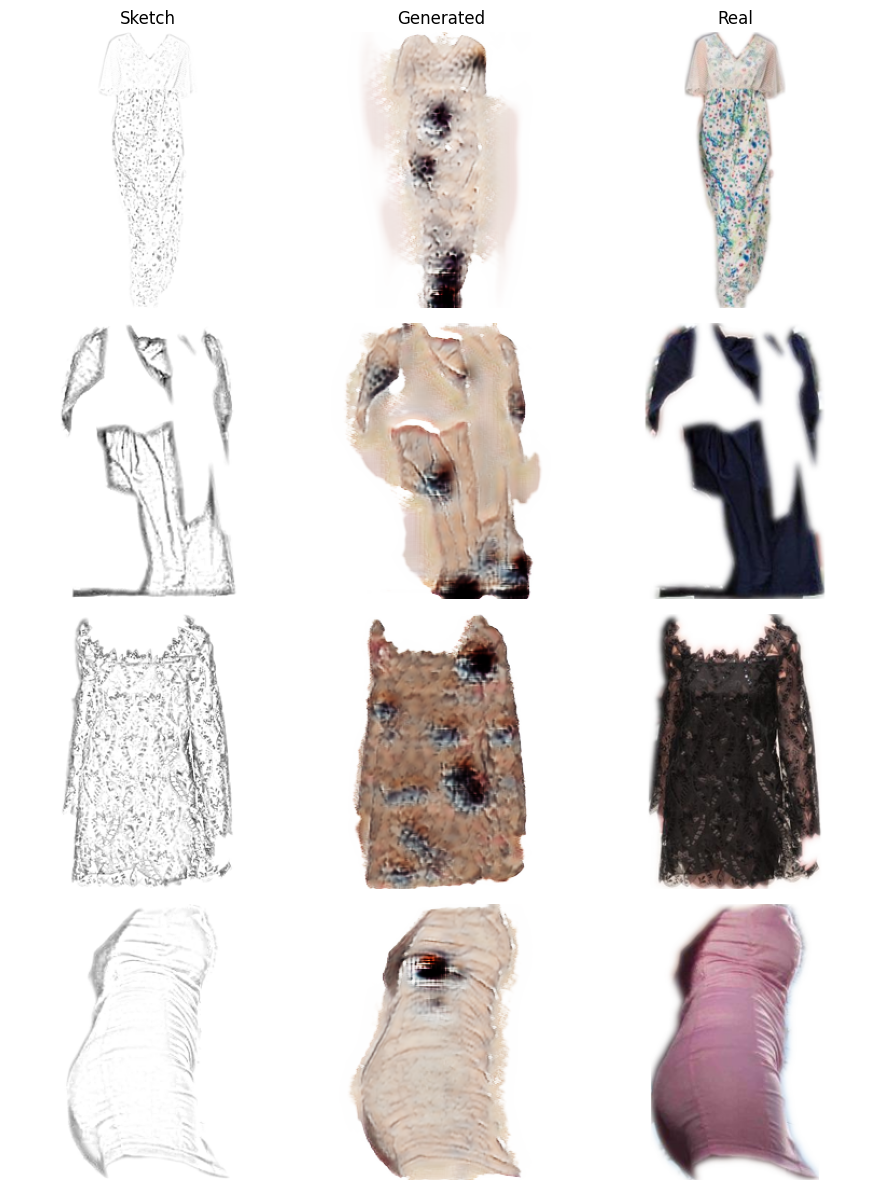

In [14]:
# Initialize model
# Using MUNIT Generator configuration
gen_params = {
    'dim': 64,
    'style_dim': 8, # Ensure this matches TrainConfig
    'n_downsample': 2,
    'n_res': 4,
    'activ': 'relu',
    'pad_type': 'reflect',
    'mlp_dim': 256
}

munit = MUNIT(gen_params).to(DEVICE)

# Path to your weights checkpoint (Update this path when running on Kaggle)
CHECKPOINT_PATH = '/kaggle/input/models/vunhuduc/sketch-munit-0-2/pytorch/default/1/0_2.pt'

# Load weights
try:
    load_generator_weights(CHECKPOINT_PATH, munit)
except FileNotFoundError:
    print(f"Warning: Checkpoint not found at {CHECKPOINT_PATH}. Model is initialized with random weights.")

# Run Evaluation
color_lookup_dict = load_color_lookup(PIPE_CFG.color_json_path) if hasattr(PIPE_CFG, 'color_json_path') else None
results = evaluate_model(munit, eval_loader, device=DEVICE, style_dim=gen_params['style_dim'], color_lookup=color_lookup_dict, style_weight=1.5)

# Show some generated samples
print("\nVisualizing some samples from evaluation set...")
munit.eval()
with torch.no_grad():
    batch = next(iter(eval_loader))
    sketch = batch['sketch'].to(DEVICE)
    real = batch['real'].to(DEVICE)
    
    # MUNIT: Encode sketch (A) to get content c_a, and use a random style code s_b to decode to domain B (image)
    c_a, _ = munit.encode(sketch, 'A')
    
    if color_lookup_dict is not None:
        batch_size = sketch.size(0)
        stems = batch['filename_stem']
        categories = batch['category']
        
        solid_imgs = []
        for i in range(batch_size):
            cat = categories[i]
            stem = stems[i]
            # Do JSON chỉ chứa ảnh train mà bộ eval dùng ảnh val (tên file khác nhau) nên lookup trả về None và bị fallback về 'white'.
            # Ta gán các màu sắc khác nhau để kiểm tra khả năng đổi màu của mô hình:
            test_colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown']
            color_lbl = test_colors[i % len(test_colors)]
            solid_img = get_solid_color_tensor(color_lbl, 1, sketch.size(2), DEVICE)
            solid_imgs.append(solid_img)
        
        solid_img_batch = torch.cat(solid_imgs, dim=0)
        _, s_b = munit.encode(solid_img_batch, 'B')
    else:
        s_b = torch.randn(sketch.size(0), gen_params['style_dim']).to(DEVICE)
    
    fake = munit.decode(c_a, s_b, 'B', style_weight=2.0)
    save_sample_grid(sketch, fake, real, max_items=4)
    


In [ ]:
import time
import torch

# 1. Calculate parameters
total_params = sum(p.numel() for p in munit.parameters())
trainable_params = sum(p.numel() for p in munit.parameters() if p.requires_grad)

gen_a_params = sum(p.numel() for p in munit.gen_a.parameters())
gen_b_params = sum(p.numel() for p in munit.gen_b.parameters())

# 2. Calculate FLOPs using a wrapper
dummy_sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
flops_str = "FLOPs calculation     : Not available (please install fvcore or thop)"

class MUNITInferenceWrapper(torch.nn.Module):
    def __init__(self, munit_model, style_dim):
        super().__init__()
        self.munit_model = munit_model
        self.style_dim = style_dim
    def forward(self, sketch):
        c_a, _ = self.munit_model.encode(sketch, 'A')
        s_b = torch.zeros(sketch.size(0), self.style_dim, device=sketch.device)
        fake = self.munit_model.decode(c_a, s_b, 'B')
        return fake

wrapper = MUNITInferenceWrapper(munit, gen_params['style_dim'])

try:
    from fvcore.nn import FlopCountAnalysis
    flops = FlopCountAnalysis(wrapper, dummy_sketch)
    flops_val = flops.total()
    flops_str = f"Total FLOPs           : {flops_val:,} ({flops_val/1e9:.2f} GFLOPs)"
except ImportError:
    try:
        import thop
        flops_val, _ = thop.profile(wrapper, inputs=(dummy_sketch,), verbose=False)
        flops_str = f"Total FLOPs           : {int(flops_val):,} ({flops_val/1e9:.2f} GFLOPs)"
    except ImportError:
        pass

print("="*50)
print("MODEL COMPLEXITY & INFERENCE SPEED EVALUATION")
print("="*50)
print(f"Total MUNIT parameters: {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Gen A parameters      : {gen_a_params:,}")
print(f"Gen B parameters      : {gen_b_params:,}")
print(flops_str)

# 3. Measure inference speed
# Warm-up runs
munit.eval()
with torch.no_grad():
    for _ in range(20):
        c_a, _ = munit.encode(dummy_sketch, 'A')
        s_b = torch.randn(1, gen_params['style_dim'], device=DEVICE)
        _ = munit.decode(c_a, s_b, 'B')

    # Sync before measuring
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
        
    start_time = time.perf_counter()
    num_runs = 100
    for _ in range(num_runs):
        c_a, _ = munit.encode(dummy_sketch, 'A')
        s_b = torch.randn(1, gen_params['style_dim'], device=DEVICE)
        _ = munit.decode(c_a, s_b, 'B')
        
    # Sync after measuring
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
        
    end_time = time.perf_counter()

total_time = end_time - start_time
avg_time_ms = (total_time / num_runs) * 1000
fps = num_runs / total_time

print(f"Average Inference Time: {avg_time_ms:.2f} ms")
print(f"Inference FPS         : {fps:.2f} frames/sec")
print("="*50)